In [2]:
import os, shutil
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras import metrics
from tensorflow.keras.losses import *
from tensorflow.keras.callbacks import *
from sklearn.utils import shuffle
%matplotlib inline
plt.style.use('ggplot')
import math

In [3]:
labels = ['PNEUMONIA','NORMAL']
img_size = 224
def get_data(data_dir):
    data=[]
    for label in labels:
#         train/PNEUMONIA
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_arr = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                data.append([resized_arr, class_num])
            except Exception as e:
                print(e)
    return data

In [4]:
train = get_data("../data/train")
test = get_data("../data/test")
val = get_data("../data/val")

In [5]:

X_train = np.array([i[0] for i in train])
y_train = np.array([i[1] for i in train])

X_val = np.array([i[0] for i in val])
y_val = np.array([i[1] for i in val])

X_test = np.array([i[0] for i in test])
y_test = np.array([i[1] for i in test])


In [6]:
# Reshape for CNN
X_train = X_train.reshape(-1, 224,224 , 1)
X_val   = X_val.reshape(-1, 224, 224, 1)
X_test  = X_test.reshape(-1, 224, 224, 1)

In [7]:
def decaying_cosine_annealing_scheduler(epoch):
    """
        A step rate scheduler for setting the learning rate for each epoch.
        :param epoch: current epoch
        :return: learning rate for current epoch
        """
    learning_rate_min = 1e-6
    original_learning_rate_max = 1e-3
    original_cycle_length = 15
    epochs_per_cycle = original_cycle_length-(int(epoch/original_cycle_length))
    learning_rate_max = original_learning_rate_max/((int(epoch/original_cycle_length))+1)
    #print(learning_rate_max,learning_rate_min, epoch, epochs_per_cycle)

    return learning_rate_min + (learning_rate_max - learning_rate_min) * \
           (1 + math.cos(math.pi * (epoch % epochs_per_cycle) / epochs_per_cycle)) / 2



In [8]:
#creating the model
inputs = Input(shape=(224,224,1))
conv1 = Conv2D(8,3,activation='relu',padding='same')(inputs)
conv1 = BatchNormalization()(conv1)
pool1 = MaxPooling2D(pool_size=(2,2))(conv1)

conv2 = Conv2D(16,3,activation='relu',padding='same')(pool1)
conv2 = BatchNormalization()(conv2)
pool2 = MaxPooling2D(pool_size=(2,2))(conv2)

conv3 = Conv2D(32,3,activation='relu',padding='same')(pool2)
conv3 = BatchNormalization()(conv3)
pool3 = MaxPooling2D(pool_size=(2,2))(conv3)

conv4 = Conv2D(64, 3, activation='relu', padding='same')(pool3)
conv4 = BatchNormalization()(conv4)
pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

conv5 = Conv2D(128, 3, activation='relu', padding='same')(pool4)
conv5 = BatchNormalization()(conv5)
drop5 = Dropout(0.25)(conv5)

x = GlobalAveragePooling2D()(drop5)
x = Dense(128, activation='relu', name='Dense_1', dtype='float32')(x)
x = Dense(64, activation='relu', name='Dense_2', dtype='float32')(x)
x = Dense(8, activation='relu', name='Dense_3', dtype='float32')(x)
x = Dense(1, activation='sigmoid', name='Output', dtype='float32')(x)


my_model = Model(inputs=[inputs], outputs=[x])

my_optimiser = Adam(learning_rate=0.00001)
my_model.compile(
    optimizer=my_optimiser,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

my_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_3 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,529 (486.44 KB)

 Trainable params: 124,033 (484.50 KB)

 Non-trainable params: 496 (1.94 KB)

In [9]:
import os
import tensorflow as tf

major_revision, minor_revision = 1, 1
model_save_path = '../models/'
log_save_path = '../logs/'

os.makedirs(model_save_path, exist_ok=True)
os.makedirs(log_save_path, exist_ok=True)

file_path = os.path.join(
    model_save_path,
    f'm{major_revision}-{minor_revision}.keras'
)

checkpoints_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=file_path,
    monitor='val_accuracy',   # safer generic name
    verbose=1,
    mode='max',
    save_best_only=True,
    save_freq='epoch'
)

learning_rate_callback = tf.keras.callbacks.LearningRateScheduler(
    decaying_cosine_annealing_scheduler,
    verbose=1
)

log_file_path = os.path.join(log_save_path, f'log-{major_revision}-{minor_revision}.txt')

def safe(v):
    return 0.0 if v is None else v


def log_epoch(epoch, logs):
    with open(log_file_path, 'a') as file:
        file.write(
            f"Epoch {epoch+1}\n"
            f"Accuracy: {safe(logs.get('accuracy')):.5f}\n"
            f"Val Accuracy: {safe(logs.get('val_accuracy')):.5f}\n"
            f"Loss: {safe(logs.get('loss')):.5f}\n"
            f"Val Loss: {safe(logs.get('val_loss')):.5f}\n"
            f"Precision: {safe(logs.get('precision')):.5f}\n"
            f"Recall: {safe(logs.get('recall')):.5f}\n"
            f"AUC: {safe(logs.get('auc')):.5f}\n"
            f"Val Precision: {safe(logs.get('val_precision')):.5f}\n"
            f"Val Recall: {safe(logs.get('val_recall')):.5f}\n"
            f"Val AUC: {safe(logs.get('val_auc')):.5f}\n"
            "------------------------\n"
        )
text_logging_callback = tf.keras.callbacks.LambdaCallback(
    on_epoch_end=log_epoch
)

my_callbacks = [
    checkpoints_callback,
    learning_rate_callback,
    text_logging_callback
]

In [33]:
import mlflow
import mlflow.tensorflow

mlflow.set_experiment("pneumonia_cnn_scratch")
mlflow.tensorflow.autolog()
with mlflow.start_run():
    history = my_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=32,
        callbacks=my_callbacks
    )


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9858 - auc: 0.9981 - loss: 0.0426 - precision: 0.9840 - recall: 0.9801
Epoch 1: val_accuracy did not improve from 0.97602


92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 187ms/step - accuracy: 0.9847 - auc: 0.9981 - loss: 0.0448 - precision: 0.9807 - recall: 0.9798 - val_accuracy: 0.9640 - val_auc: 0.9909 - val_loss: 0.1115 - val_precision: 0.9663 - val_recall: 0.9617 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.000989084726566536.
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.9968 - auc: 0.9999 - loss: 0.0121 - precision: 0.9950 - recall: 0.9968
Epoch 2: val_accuracy did not improve from 0.97602
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 239ms/step - accuracy: 0.9959 - auc: 0.9999 - loss: 0.0129 - precision: 0.9947 - recall: 0.9947 - val_accuracy: 0.9376 - val_auc: 0.9849 - val_loss: 0.1843 - val_precision: 0.9645 - val_recall: 0.9091 - learning_rate: 9.8908e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0009568159560924792.
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.9891 - auc: 0.9983 - loss: 0.0315 - precision: 0.9841 - recall: 0.9880


92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 200ms/step - accuracy: 0.9993 - auc: 1.0000 - loss: 0.0024 - precision: 0.9991 - recall: 0.9991 - val_accuracy: 0.9760 - val_auc: 0.9888 - val_loss: 0.1073 - val_precision: 0.9716 - val_recall: 0.9809 - learning_rate: 4.4829e-04

Epoch 10: LearningRateScheduler setting learning rate to 0.0003461460113097139.
Epoch 10/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9995 - auc: 1.0000 - loss: 0.0020 - precision: 0.9987 - recall: 1.0000
Epoch 10: val_accuracy did not improve from 0.97602
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 210ms/step - accuracy: 0.9986 - auc: 1.0000 - loss: 0.0038 - precision: 0.9965 - recall: 1.0000 - val_accuracy: 0.9592 - val_auc: 0.9827 - val_loss: 0.1708 - val_precision: 0.9615 - val_recall: 0.9569 - learning_rate: 3.4615e-04

Epoch 11: LearningRateScheduler setting learning rate to 0.00025075000000000016.
Epoch 11/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.9994 - auc: 1.0000 - loss: 0.0018 - precision: 1.0000 - reca

2026/06/16 17:14:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [11]:
test_loss, test_acc, test_precision, test_recall, test_auc = my_model.evaluate(X_test, y_test)
print(test_acc, test_precision, test_recall, test_auc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.7965 - auc: 0.8368 - loss: 0.9854 - precision: 0.7744 - recall: 0.6453
0.7964743375778198 0.7743589878082275 0.6452991366386414 0.8367632031440735


In [34]:
y_pred_prob = my_model.predict(X_test)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step


In [35]:
y_pred = (y_pred_prob > 0.5).astype(int)

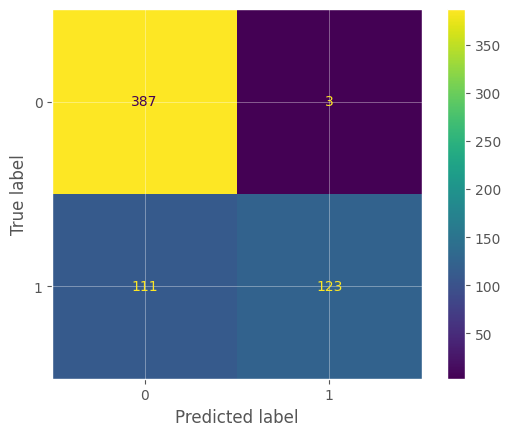

In [36]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [43]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB3

base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # frozen in phase 1

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)

# Better head: don't bottleneck too aggressively
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

bnet3 = Model(inputs, outputs)

bnet3.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),  # higher LR ok when backbone frozen
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

bnet3.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,200,688 (42.73 MB)

 Trainable params: 413,569 (1.58 MB)

 Non-trainable params: 10,787,119 (41.15 MB)

In [26]:
from tensorflow.keras.applications import DenseNet121

base = DenseNet121(weights="imagenet", include_top=False, input_shape=(224,224,3))
base.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = base(inputs, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(8, activation='relu')(x)

outputs = layers.Dense(1, activation='sigmoid')(x)


dn121 = Model(inputs, outputs)

dn121.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 33s 1us/step


In [28]:
# # convert to RGB
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_val_rgb   = np.repeat(X_val, 3, axis=-1)
X_test_rgb  = np.repeat(X_test, 3, axis=-1)


(624,)

In [42]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

# EfficientNetB3 has its own preprocessing — do NOT use rescale=1./255
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ← correct preprocessing
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=(0.8, 1.2)
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input   # ← same here, no rescale
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

batch_size = 32

train_generator = train_datagen.flow(
    X_train_rgb, y_train,
    batch_size=batch_size,
    shuffle=True
)

val_generator = val_datagen.flow(
    X_val_rgb, y_val,
    batch_size=batch_size,
    shuffle=False
)

test_generator = test_datagen.flow(
    X_test_rgb, y_test,
    batch_size=16,
    shuffle=False
)

In [44]:
import os
import tensorflow as tf

major_revision, minor_revision = 1, 2  # new version for transfer learning

model_save_path = '../models/'
log_save_path = '../logs/'

os.makedirs(model_save_path, exist_ok=True)
os.makedirs(log_save_path, exist_ok=True)

file_path = os.path.join(
    model_save_path,
    f'm{major_revision}-{minor_revision}.keras'
)

checkpoints_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=file_path,
    monitor='val_auc',
    verbose=1,
    mode='max',
    save_best_only=True,
    save_freq='epoch'
)

learning_rate_callback = tf.keras.callbacks.LearningRateScheduler(
    decaying_cosine_annealing_scheduler,
    verbose=1
)

log_file_path = os.path.join(
    log_save_path,
    f'log-{major_revision}-{minor_revision}.txt'
)

def safe(v):
    return 0.0 if v is None else v


def log_epoch(epoch, logs):
    with open(log_file_path, 'a') as file:
        file.write(
            f"\nEpoch {epoch+1}\n"
            f"Loss: {safe(logs.get('loss')):.5f}\n"
            f"Accuracy: {safe(logs.get('accuracy')):.5f}\n"
            f"Val Loss: {safe(logs.get('val_loss')):.5f}\n"
            f"Val Accuracy: {safe(logs.get('val_accuracy')):.5f}\n"
            f"AUC: {safe(logs.get('auc')):.5f}\n"
            f"Val AUC: {safe(logs.get('val_auc')):.5f}\n"
            "------------------------\n"
        )

text_logging_callback = tf.keras.callbacks.LambdaCallback(
    on_epoch_end=log_epoch
)

my_callbacks_bnet3 = [
    checkpoints_callback,
    learning_rate_callback,
    text_logging_callback
]

In [45]:
mlflow.set_experiment("pneumonia_efficientnetb3")
mlflow.tensorflow.autolog()
with mlflow.start_run():
    history = bnet3.fit(
        train_generator,
        validation_data=val_generator,
        epochs=20,
        callbacks=my_callbacks_bnet3
    )

2026/06/16 18:03:16 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.NumpyArrayIterator'>. Dataset logging skipped.
2026/06/16 18:03:16 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.NumpyArrayIterator'>. Dataset logging skipped.



Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 881ms/step - accuracy: 0.8260 - auc: 0.9089 - loss: 0.4246
Epoch 1: val_auc improved from None to 0.98452, saving model to ../models/m1-2.keras

Epoch 1: finished saving model to ../models/m1-2.keras


92/92 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.8762 - auc: 0.9466 - loss: 0.3174 - val_accuracy: 0.8633 - val_auc: 0.9845 - val_loss: 0.3178 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.000989084726566536.
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 930ms/step - accuracy: 0.9116 - auc: 0.9704 - loss: 0.2213
Epoch 2: val_auc improved from 0.98452 to 0.98852, saving model to ../models/m1-2.keras

Epoch 2: finished saving model to ../models/m1-2.keras


92/92 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.9184 - auc: 0.9724 - loss: 0.2098 - val_accuracy: 0.8873 - val_auc: 0.9885 - val_loss: 0.2737 - learning_rate: 9.8908e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0009568159560924792.
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9141 - auc: 0.9743 - loss: 0.2027
Epoch 3: val_auc did not improve from 0.98852


92/92 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9224 - auc: 0.9759 - loss: 0.1944 - val_accuracy: 0.9161 - val_auc: 0.9877 - val_loss: 0.1988 - learning_rate: 9.5682e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0009046039886902864.
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 871ms/step - accuracy: 0.9202 - auc: 0.9779 - loss: 0.1890
Epoch 4: val_auc improved from 0.98852 to 0.98888, saving model to ../models/m1-2.keras

Epoch 4: finished saving model to ../models/m1-2.keras


...

92/92 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.9466 - auc: 0.9879 - loss: 0.1330 - val_accuracy: 0.9353 - val_auc: 0.9880 - val_loss: 0.1455 - learning_rate: 6.5485e-04

Epoch 8: LearningRateScheduler setting learning rate to 0.000552711967402193.
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9446 - auc: 0.9877 - loss: 0.1401
Epoch 8: val_auc did not improve from 0.98888
92/92 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.9459 - auc: 0.9882 - loss: 0.1358 - val_accuracy: 0.9281 - val_auc: 0.9881 - val_loss: 0.1556 - learning_rate: 5.5271e-04

Epoch 9: LearningRateScheduler setting learning rate to 0.00044828803259780724.
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9527 - auc: 0.9916 - loss: 0.1138
Epoch 9: val_auc improved from 0.98888 to 0.98934, saving model to ../models/m1-2.keras

Epoch 9: finished saving model to ../models/m1-2.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9507 - auc: 0.9898 - loss: 0.1251 - val_accuracy: 

92/92 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.9493 - auc: 0.9886 - loss: 0.1273 - val_accuracy: 0.9376 - val_auc: 0.9900 - val_loss: 0.1302 - learning_rate: 3.4615e-04

Epoch 11: LearningRateScheduler setting learning rate to 0.00025075000000000016.
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 948ms/step - accuracy: 0.9550 - auc: 0.9896 - loss: 0.1215
Epoch 11: val_auc improved from 0.98998 to 0.99068, saving model to ../models/m1-2.keras

Epoch 11: finished saving model to ../models/m1-2.keras


92/92 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - accuracy: 0.9558 - auc: 0.9912 - loss: 0.1142 - val_accuracy: 0.9472 - val_auc: 0.9907 - val_loss: 0.1272 - learning_rate: 2.5075e-04

Epoch 12: LearningRateScheduler setting learning rate to 0.0001662692621237505.
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9529 - auc: 0.9895 - loss: 0.1269
Epoch 12: val_auc did not improve from 0.99068
92/92 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.9527 - auc: 0.9892 - loss: 0.1265 - val_accuracy: 0.9472 - val_auc: 0.9902 - val_loss: 0.1333 - learning_rate: 1.6627e-04

Epoch 13: LearningRateScheduler setting learning rate to 9.639601130971382e-05.
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9621 - auc: 0.9901 - loss: 0.1144
Epoch 13: val_auc did not improve from 0.99068
92/92 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9575 - auc: 0.9901 - loss: 0.1156 - val_accuracy: 0.9448 - val_auc: 0.9905 - val_loss: 0.1369 - learning_rate: 9.6396e-05

Epoch 14: LearningR

92/92 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.9463 - auc: 0.9866 - loss: 0.1392 - val_accuracy: 0.9520 - val_auc: 0.9908 - val_loss: 0.1161 - learning_rate: 4.9374e-04

Epoch 17: LearningRateScheduler setting learning rate to 0.00047529173254165356.
Epoch 17/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 917ms/step - accuracy: 0.9451 - auc: 0.9903 - loss: 0.1255
Epoch 17: val_auc did not improve from 0.99076
92/92 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.9466 - auc: 0.9902 - loss: 0.1225 - val_accuracy: 0.9424 - val_auc: 0.9889 - val_loss: 0.1308 - learning_rate: 4.7529e-04

Epoch 18: LearningRateScheduler setting learning rate to 0.0004455669548757735.
Epoch 18/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 922ms/step - accuracy: 0.9556 - auc: 0.9906 - loss: 0.1203
Epoch 18: val_auc did not improve from 0.99076
92/92 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.9575 - auc: 0.9907 - loss: 0.1173 - val_accuracy: 0.9424 - val_auc: 0.9901 - val_loss: 0.1392 - learning_rate: 4.4557e-04

Epoch 19: Learn

2026/06/16 18:40:41 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: '>=' not supported between instances of 'slice' and 'int'
2026/06/16 18:40:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/16 18:40:41 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [51]:
test_loss, test_acc, test_precision, test_recall, test_auc = bnet3.evaluate(test_generator)

print(test_acc, test_precision, test_recall, test_auc)

39/39 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8990 - auc: 0.9731 - loss: 0.2759


ValueError: not enough values to unpack (expected 5, got 3)

39/39 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step


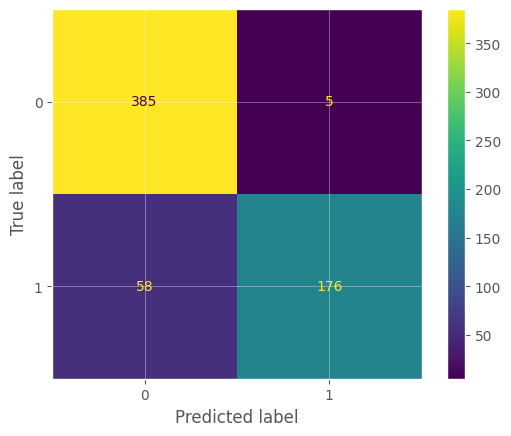

In [52]:
# Predict
y_pred_prob = bnet3.predict(test_generator)

# Convert
y_pred = (y_pred_prob > 0.5).astype(int)

# True labels
y_true = y_test

# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(precision, recall, f1)

0.9723756906077348 0.7521367521367521 0.8481927710843373


In [46]:
# DenseNet121 version
major_revision, minor_revision = 1, 3

model_save_path = '../models/'
log_save_path = '../logs/'

os.makedirs(model_save_path, exist_ok=True)
os.makedirs(log_save_path, exist_ok=True)

# Model checkpoint path
file_path = os.path.join(
    model_save_path,
    f'm{major_revision}-{minor_revision}.keras'
)

checkpoints_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=file_path,
    monitor='val_auc',
    verbose=1,
    mode='max',
    save_best_only=True,
    save_freq='epoch'
)

# Learning-rate scheduler
learning_rate_callback = tf.keras.callbacks.LearningRateScheduler(
    decaying_cosine_annealing_scheduler,
    verbose=1
)

# Log file path
log_file_path = os.path.join(
    log_save_path,
    f'log-{major_revision}-{minor_revision}.txt'
)

def safe(v):
    return 0.0 if v is None else v

def log_epoch(epoch, logs):
    with open(log_file_path, 'a') as file:
        file.write(
            f"\nEpoch {epoch+1}\n"
            f"Loss: {safe(logs.get('loss')):.5f}\n"
            f"Accuracy: {safe(logs.get('accuracy')):.5f}\n"
            f"Val Loss: {safe(logs.get('val_loss')):.5f}\n"
            f"Val Accuracy: {safe(logs.get('val_accuracy')):.5f}\n"
            f"AUC: {safe(logs.get('auc')):.5f}\n"
            f"Val AUC: {safe(logs.get('val_auc')):.5f}\n"
            "------------------------\n"
        )

text_logging_callback = tf.keras.callbacks.LambdaCallback(
    on_epoch_end=log_epoch
)

# Callbacks for DenseNet121 v1.3
my_callbacks_densenet121 = [
    checkpoints_callback,
    learning_rate_callback,
    text_logging_callback
]

In [47]:

mlflow.set_experiment("pneumonia_densenet121")
mlflow.tensorflow.autolog()
with mlflow.start_run():
    history = dn121.fit(
        train_generator,
        validation_data=val_generator,
        epochs=20,
        callbacks=my_callbacks_densenet121
)



2026/06/21 15:02:48 INFO mlflow.tracking.fluent: Experiment with name 'pneumonia_densenet121' does not exist. Creating a new experiment.
2026/06/21 15:02:49 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.NumpyArrayIterator'>. Dataset logging skipped.
2026/06/21 15:02:49 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.NumpyArrayIterator'>. Dataset logging skipped.



Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7545 - loss: 0.5513

C:\Users\DELL\Desktop\pnemunia_detection\.venv\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:329: UserWarning: Can save best model only with val_auc available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to ../models/m1-3.keras


92/92 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.8337 - loss: 0.3829 - val_accuracy: 0.8801 - val_loss: 0.3222 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.000989084726566536.
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9007 - loss: 0.2599
Epoch 2: finished saving model to ../models/m1-3.keras


...

92/92 ━━━━━━━━━━━━━━━━━━━━ 287s 3s/step - accuracy: 0.9088 - loss: 0.2132 - val_accuracy: 0.9305 - val_loss: 0.1888 - learning_rate: 7.5025e-04

Epoch 7: LearningRateScheduler setting learning rate to 0.0006548539886902864.
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9395 - loss: 0.1556
Epoch 7: finished saving model to ../models/m1-3.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 248s 3s/step - accuracy: 0.9395 - loss: 0.1560 - val_accuracy: 0.9305 - val_loss: 0.1957 - learning_rate: 6.5485e-04

Epoch 8: LearningRateScheduler setting learning rate to 0.000552711967402193.
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9310 - loss: 0.1747
Epoch 8: finished saving model to ../models/m1-3.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 256s 3s/step - accuracy: 0.9330 - loss: 0.1695 - val_accuracy: 0.9161 - val_loss: 0.2370 - learning_rate: 5.5271e-04

Epoch 9: LearningRateScheduler setting learning rate to 0.00044828803259780724.
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - a

92/92 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.9415 - loss: 0.1480 - val_accuracy: 0.9424 - val_loss: 0.1631 - learning_rate: 4.4829e-04

Epoch 10: LearningRateScheduler setting learning rate to 0.0003461460113097139.
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9446 - loss: 0.1355
Epoch 10: finished saving model to ../models/m1-3.keras


92/92 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.9418 - loss: 0.1451 - val_accuracy: 0.9329 - val_loss: 0.1615 - learning_rate: 3.4615e-04

Epoch 11: LearningRateScheduler setting learning rate to 0.00025075000000000016.
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9455 - loss: 0.1436
Epoch 11: finished saving model to ../models/m1-3.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.9490 - loss: 0.1368 - val_accuracy: 0.9376 - val_loss: 0.1696 - learning_rate: 2.5075e-04

Epoch 12: LearningRateScheduler setting learning rate to 0.0001662692621237505.
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9452 - loss: 0.1371
Epoch 12: finished saving model to ../models/m1-3.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.9425 - loss: 0.1445 - val_accuracy: 0.9353 - val_loss: 0.1714 - learning_rate: 1.6627e-04

Epoch 13: LearningRateScheduler setting learning rate to 9.639601130971382e-05.
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s

92/92 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.9490 - loss: 0.1366 - val_accuracy: 0.9496 - val_loss: 0.1538 - learning_rate: 9.6396e-05

Epoch 14: LearningRateScheduler setting learning rate to 4.418404390752081e-05.
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9511 - loss: 0.1297
Epoch 14: finished saving model to ../models/m1-3.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 365s 4s/step - accuracy: 0.9524 - loss: 0.1305 - val_accuracy: 0.9424 - val_loss: 0.1602 - learning_rate: 4.4184e-05

Epoch 15: LearningRateScheduler setting learning rate to 1.191527343346406e-05.
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9449 - loss: 0.1452
Epoch 15: finished saving model to ../models/m1-3.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.9476 - loss: 0.1313 - val_accuracy: 0.9472 - val_loss: 0.1578 - learning_rate: 1.1915e-05

Epoch 16: LearningRateScheduler setting learning rate to 0.000493744514089365.
Epoch 16/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/s

2026/06/21 16:25:56 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: '>=' not supported between instances of 'slice' and 'int'
2026/06/21 16:25:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/21 16:25:56 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


39/39 ━━━━━━━━━━━━━━━━━━━━ 37s 808ms/step


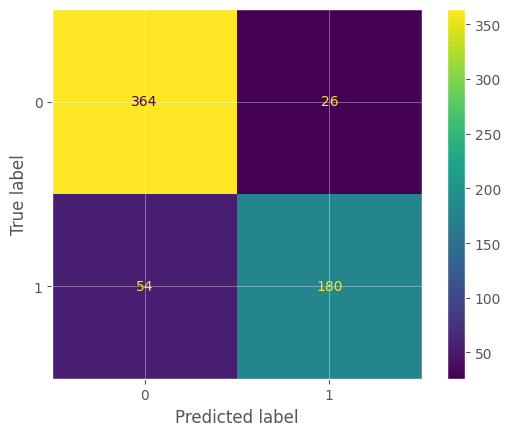

In [54]:
# Predict
y_pred_prob = dn121.predict(test_generator)

# Convert
y_pred = (y_pred_prob > 0.5).astype(int)

# True labels
y_true = y_test

# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [55]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(precision, recall, f1)

0.8737864077669902 0.7692307692307693 0.8181818181818182
